# Modele de Remboursement Anticipé (RA) — Approche Hazard Discret IFRS 9

Ce notebook documente et explique pas à pas le modèle de projection du taux de Remboursement Anticipé (RA) sur un portefeuille de prêts immobiliers, dans le cadre IFRS 9.

---

## Objectif general

Modéliser la **probabilité mensuelle qu'un prêt soit remboursé par anticipation** à chaque mois de sa vie, en tenant compte :
- de la durée de vie du prêt (age)
- des conditions de marché (Euribor 3M)
- des caractéristiques du client (taux contractuel, âge)
- du régime macroéconomique (crise 2008, COVID, etc.)

Le modèle suit une **approche de hasard discret (discrete-time hazard model)** : on modélise la probabilité conditionnelle d'événement à chaque pas de temps, conditionnellement à la survie jusqu'à ce pas.

---

## Table des matieres

1. Parametres globaux et utilitaires
2. Chargement des données
3. Split Train / Calibration / Test
4. Construction du panel de hasard discret (Train)
5. Estimation du modele GLM logistique
6. Fonctions de prediction et courbe forward IFRS 9
7. Calibration IFRS 9 sur le jeu de calibration
8. Backtest sur le jeu de test
9. Resultats et interpretation


---
## 1. Parametres globaux et utilitaires

### Ce que fait ce bloc

On définit l'ensemble des **constantes** qui pilotent tout le pipeline, ainsi que des **fonctions utilitaires** réutilisées partout.


In [1]:
import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.special import expit, logit

# =========================================================
# PARAMETRES
# =========================================================
ID_COL        = "ID"
DATE_COL      = "Date_origination"
DARRET_RAW    = "DARRET"
DARRET_COL    = "DARRET_RA"

MAX_AGE       = 40
CUT1, CUT2    = 12, 24

Q_TRAIN_END   = 0.70
Q_CALIB_END   = 0.80

# plus petit qu'avant pour eviter l'explosion memoire
PER_T         = 8_000
BATCH         = 150_000
MAXITER       = 120

### Explication des parametres

| Paramètre | Valeur | Rôle |
|---|---|---|
| `MAX_AGE` | 40 mois | Horizon maximum du modèle — on tronque à 40 mois après origination |
| `CUT1`, `CUT2` | 12, 24 mois | Seuils pour la calibration IFRS9 en trois tranches d'horizon |
| `Q_TRAIN_END` | 0.70 | 70e percentile des dates d'origination — fin de la période d'entraînement |
| `Q_CALIB_END` | 0.80 | 80e percentile — fin de la période de calibration |
| `PER_T` | 8 000 | Nombre max de lignes échantillonnées par mois d'âge dans le panel train |
| `BATCH` | 150 000 | Taille des batchs pour la prédiction (évite les OOM) |


In [ ]:
# =========================================================
# UTILS
# =========================================================
def month_diff_ts(a: pd.Series, b: pd.Timestamp) -> pd.Series:
    a = pd.to_datetime(a, errors="coerce")
    return (b.year - a.dt.year) * 12 + (b.month - a.dt.month)

def normalize_from_params(series, mu, sd):
    sd = sd if (pd.notna(sd) and sd > 0) else 1.0
    return (series - mu) / sd

def add_euribor(df_base_base_base_base_base_base_in, e3m_full, date_obs_col="date_obs"):
    out = df_in.sort_values(date_obs_col).copy()
    ref = e3m_full.sort_values("date_obs").copy()
    out = pd.merge_asof(out, ref, on="date_obs", direction="backward")
    out["E3M"] = out["E3M"].ffill().bfill()
    return out

def map_regime_from_date(date_series):
    """
    Regimes calendaires compactes pour capter:
    - crise 2007-2009
    - regime 'normal' 2010-2019
    - covid 2020-2021
    - post 2022+
    """
    y = pd.to_datetime(date_series, errors="coerce").dt.year
    out = pd.Series(index=date_series.index, dtype="object")

    out.loc[y <= 2006] = "PRE_2007"
    out.loc[(y >= 2007) & (y <= 2009)] = "CRISIS_2007_2009"
    out.loc[(y >= 2010) & (y <= 2019)] = "NORMAL_2010_2019"
    out.loc[(y >= 2020) & (y <= 2021)] = "COVID_2020_2021"
    out.loc[y >= 2022] = "POST_2022_PLUS"

    return out

REGIME_CATS = [
    "PRE_2007",
    "CRISIS_2007_2009",
    "NORMAL_2010_2019",
    "COVID_2020_2021",
    "POST_2022_PLUS",
]

### Explication des fonctions utilitaires

**`month_diff_ts`** : calcule la différence en mois entre une série de dates et une date de référence fixe. Utilisée pour calculer l'âge d'un prêt à une date d'observation donnée.

**`normalize_from_params`** : standardisation (centrage-réduction) d'une variable numérique à partir de paramètres précalculés sur le train. Formule : `(x - mu) / sd`. Le fait de passer `mu` et `sd` en paramètre garantit que la même transformation est appliquée de façon cohérente sur train, calibration et test.

**`add_euribor`** : joint l'Euribor 3M mensuel à chaque ligne du panel via un **merge_asof** (fusion par valeur approchante). Pour chaque date d'observation, on prend l'Euribor du mois précédent le plus proche. C'est une jointure temporelle "backward" : on ne regarde jamais dans le futur.

**`map_regime_from_date`** : encode la date d'observation en régime macroéconomique. Ce découpage capture les grandes ruptures structurelles susceptibles d'affecter le comportement de remboursement anticipé :
- `PRE_2007` : période de taux élevés pré-crise
- `CRISIS_2007_2009` : choc financier global
- `NORMAL_2010_2019` : longue période de taux bas
- `COVID_2020_2021` : choc pandémique
- `POST_2022_PLUS` : cycle de remontée rapide des taux


---
## 2. Chargement des donnees

### Ce que fait ce bloc

Chargement du portefeuille de prêts et de la série Euribor 3M mensuelle.


In [19]:
# =========================================================
# 0) CHARGEMENT
# =========================================================
df_base = pd.read_csv("Export_ER_Agrege.csv", sep=";")

df_base["RA"] = pd.to_numeric(df_base["RA"], errors="coerce").fillna(0)
df_base["EVENT"] = (df_base["RA"] > 0).astype(int)

df_base[DATE_COL]   = pd.to_datetime(df_base[DATE_COL], errors="coerce")
df_base["AGE_PRET"] = pd.to_numeric(df_base["AGE_PRET"], errors="coerce")
df_base["Tx"]       = pd.to_numeric(df_base["Tx"], errors="coerce")
df_base["AGE_CLI"]  = pd.to_numeric(df_base["AGE_CLI"], errors="coerce")
df_base[DARRET_RAW] = pd.to_datetime(df_base[DARRET_RAW], errors="coerce")

# date de RA propre
df_base[DARRET_COL] = df_base[DARRET_RAW].where(df_base["EVENT"] == 1, pd.NaT)

# Euribor mensuel
euribor_raw = pd.read_csv("euribor.csv", sep=",")
e3m_full = (
    euribor_raw.rename(columns={"date": "date_obs", "3m": "E3M"})[["date_obs", "E3M"]]
    .assign(
        date_obs=lambda d: pd.to_datetime(d["date_obs"], errors="coerce")
                           .dt.to_period("M").dt.to_timestamp(),
        E3M=lambda d: pd.to_numeric(d["E3M"], errors="coerce")
    )
    .dropna()
    .sort_values("date_obs")
    .reset_index(drop=True)
)

# AGE_CONTRAT
df_base['AGE_CONTRAT'] = df_base['B_MAT'] - df_base['B_RESMAT']

# Diagnostic avant nettoyage
n_negatifs = (df_base['AGE_CONTRAT'] < 0).sum()
print(f"Contrats avec AGE_CONTRAT < 0 (B_RESMAT > B_MAT) : {n_negatifs} ({n_negatifs/len(df_base):.2%})")
print(f"Aperçu des cas problématiques :")
print(df_base.loc[df_base['AGE_CONTRAT'] < 0, ['B_MAT', 'B_RESMAT', 'AGE_CONTRAT']].describe().round(2))

# Ces cas sont économiquement incohérents : la durée résiduelle ne peut pas
# dépasser la durée initiale. Suppression.
df_base = df_base[df_base['AGE_CONTRAT'] >= 0].copy()
print(f"\nAprès suppression : {len(df_base):,} observations restantes")

# Vérifications de cohérence
assert (df_base['AGE_CONTRAT'] >= 0).all(), "ERREUR : AGE_CONTRAT < 0 détecté"
assert (df_base['AGE_CONTRAT'] <= df_base['B_MAT']).all(), "ERREUR : AGE_CONTRAT > B_MAT"
print(f'AGE_CONTRAT : cohérence vérifiée ✓')
print(f'  Range : [{df_base["AGE_CONTRAT"].min():.0f}, {df_base["AGE_CONTRAT"].max():.0f}] mois')
print(f'  Médiane : {df_base["AGE_CONTRAT"].median():.0f} mois')

# Ratio d'avancement dans la vie du contrat [0, 1]
df_base['RATIO_AGE'] = df_base['AGE_CONTRAT'] / df_base['B_MAT']


Contrats avec AGE_CONTRAT < 0 (B_RESMAT > B_MAT) : 0 (0.00%)
Aperçu des cas problématiques :
       B_MAT  B_RESMAT  AGE_CONTRAT
count    0.0       0.0          0.0
mean     NaN       NaN          NaN
std      NaN       NaN          NaN
min      NaN       NaN          NaN
25%      NaN       NaN          NaN
50%      NaN       NaN          NaN
75%      NaN       NaN          NaN
max      NaN       NaN          NaN

Après suppression : 90,375 observations restantes
AGE_CONTRAT : cohérence vérifiée ✓
  Range : [0, 168] mois
  Médiane : 27 mois


### Explication

**Fichier principal (`Export_ER_Agrege.csv`)** : une ligne = un prêt. Les colonnes clés sont :

| Colonne | Description |
|---|---|
| `ID` | Identifiant unique du prêt |
| `Date_origination` | Date de mise en place du prêt |
| `AGE_PRET` | Age du prêt en mois à la date de snapshot |
| `Tx` | Taux d'intérêt contractuel |
| `AGE_CLI` | Age du client |
| `RA` | Montant de remboursement anticipé (0 si aucun événement) |
| `DARRET` | Date effective de remboursement anticipé (NaT si pas d'événement) |
| `produit` | Type de produit |

**Variable cible `EVENT`** : indicateur binaire, vaut 1 si `RA > 0` (il y a eu un remboursement anticipé), 0 sinon.

**Euribor 3M** : série mensuelle externe utilisée comme variable macroéconomique. Jointure temporelle backward pour ne jamais utiliser une valeur future.


---
## 3. Split Train / Calibration / Test par date d'origination

### Ce que fait ce bloc

On découpe le portefeuille en trois sous-ensembles **sans chevauchement temporel**, en se basant sur la date d'origination des prêts.


In [4]:
# =========================================================
# 1) SPLIT TRAIN / CALIB / TEST PAR ORIGINATION
# =========================================================
df_base = df.copy()

df_base["T_STOP_TRUE"]  = df_base["AGE_PRET"].astype("Int64")
df_base["T_STOP_PANEL"] = df_base["AGE_PRET"].clip(0, MAX_AGE).astype("Int64")

base_dates = df_base[[ID_COL, DATE_COL]].drop_duplicates().dropna()
d_train_end = base_dates[DATE_COL].quantile(Q_TRAIN_END)
d_calib_end = base_dates[DATE_COL].quantile(Q_CALIB_END)

train_ids = set(base_dates.loc[base_dates[DATE_COL] <= d_train_end, ID_COL])
calib_ids = set(base_dates.loc[(base_dates[DATE_COL] > d_train_end) & (base_dates[DATE_COL] <= d_calib_end), ID_COL]) - train_ids
test_ids  = set(base_dates.loc[base_dates[DATE_COL] > d_calib_end, ID_COL]) - train_ids - calib_ids

print("TRAIN end:", pd.to_datetime(d_train_end).date(), "| CALIB end:", pd.to_datetime(d_calib_end).date())
print("Contracts train/calib/test:", len(train_ids), len(calib_ids), len(test_ids))

# produit2 top TRAIN
top_prod = df_base.loc[df_base[ID_COL].isin(train_ids), "produit"].value_counts().head(15).index
prod_cats = list(top_prod) + ["Other"]
df_base["produit2"] = df_base["produit"].where(df_base["produit"].isin(top_prod), "Other")

TRAIN end: 2019-10-19 | CALIB end: 2020-08-15
Contracts train/calib/test: 63279 9033 18063


### Explication

Le split est réalisé par **percentile de date d'origination** (et non par date d'observation), ce qui garantit l'absence de fuite de données temporelle.

```
|-------- TRAIN (70%) --------|-- CALIB (10%) --|-- TEST (20%) -->
                        2019-10-19         2020-08-15
```

**Résultats obtenus :**
- TRAIN end : **2019-10-19** — 63 279 contrats
- CALIB end : **2020-08-15** — 9 033 contrats
- TEST : **18 063 contrats** (originations postérieures au 80e percentile)

**Pourquoi ce découpage en trois jeux ?**
- Le **train** sert à estimer les paramètres du modèle logistique.
- La **calibration** sert à ajuster les probabilités brutes pour qu'elles reproduisent fidèlement les taux observés (correction de biais systématique).
- Le **test** sert à valider l'ensemble du pipeline sur des données jamais vues, ni pour l'estimation ni pour la calibration.

**`produit2`** : les 15 produits les plus fréquents dans le train sont conservés tels quels ; tous les autres sont regroupés en `"Other"`. La variable sera ignorée si une seule modalité est observée dans l'échantillon sous-tiré (`train_fit`), comme c'est le cas ici.


---
## 4. Construction du panel de hasard discret (Train)

### Ce que fait ce bloc

On transforme le fichier "un prêt = une ligne" en **panel long** : pour chaque prêt et pour chaque mois d'âge de 0 à `T_STOP_PANEL`, on crée une ligne. C'est le format requis par le modèle de hasard discret.


In [5]:
# =========================================================
# 2) PANEL TRAIN (HAZARD DISCRET)
# =========================================================
panel_train = (
    df_base.loc[
        df_base[ID_COL].isin(train_ids),
        [ID_COL, "EVENT", "T_STOP_TRUE", "T_STOP_PANEL", DATE_COL, "Tx", "AGE_CLI", "produit2"]
    ]
    .dropna(subset=[ID_COL, "T_STOP_PANEL", DATE_COL, "Tx", "AGE_CLI"])
    .assign(t_int=lambda d: d["T_STOP_PANEL"].map(lambda T: list(range(int(T) + 1))))
    .explode("t_int", ignore_index=True)
)

panel_train["t_int"] = panel_train["t_int"].astype(int)

panel_train["y"] = (
    (panel_train["EVENT"] == 1)
    & panel_train["T_STOP_TRUE"].notna()
    & (panel_train["T_STOP_TRUE"] <= MAX_AGE)
    & (panel_train["t_int"] == panel_train["T_STOP_TRUE"].astype(int))
).astype(int)

panel_train["date_obs"] = (
    panel_train[DATE_COL].dt.to_period("M") + panel_train["t_int"]
).dt.to_timestamp()

panel_train = add_euribor(panel_train, e3m_full, date_obs_col="date_obs")

# structure
t_cats = list(range(0, MAX_AGE + 1))
panel_train["t_cat"] = pd.Categorical(panel_train["t_int"], categories=t_cats, ordered=True)
panel_train["regime_obs"] = pd.Categorical(
    map_regime_from_date(panel_train["date_obs"]),
    categories=REGIME_CATS
)
panel_train["produit2"] = pd.Categorical(panel_train["produit2"], categories=prod_cats)

# standardisation sur TRAIN
mu_tx,  sd_tx  = panel_train["Tx"].mean(),      panel_train["Tx"].std(ddof=0)
mu_e3m, sd_e3m = panel_train["E3M"].mean(),     panel_train["E3M"].std(ddof=0)
mu_age, sd_age = panel_train["AGE_CLI"].mean(), panel_train["AGE_CLI"].std(ddof=0)

panel_train["Tx_z"]      = normalize_from_params(panel_train["Tx"],      mu_tx,  sd_tx)
panel_train["E3M_z"]     = normalize_from_params(panel_train["E3M"],     mu_e3m, sd_e3m)
panel_train["AGE_CLI_z"] = normalize_from_params(panel_train["AGE_CLI"], mu_age, sd_age)

panel_train = panel_train.dropna(subset=["Tx_z", "E3M_z", "AGE_CLI_z", "regime_obs"])
print("TRAIN panel rows:", len(panel_train), "| events:", int(panel_train["y"].sum()))

# sous-echantillonnage par t
parts = []
for t_val in range(0, MAX_AGE + 1):
    g = panel_train.loc[panel_train["t_int"] == t_val]
    if len(g) == 0:
        continue
    parts.append(g.sample(n=min(len(g), PER_T), random_state=0))

train_fit = pd.concat(parts, ignore_index=True)

use_prod = train_fit["produit2"].nunique(dropna=True) > 1
if not use_prod:
    print("⚠ produit2 ignoré (une seule modalité observée dans train_fit)")

TRAIN panel rows: 1975732 | events: 35636
⚠ produit2 ignoré (une seule modalité observée dans train_fit)


### Explication : le modele de hasard discret

#### Principe fondamental

Dans un modèle de survie à temps discret, on modélise la **probabilité conditionnelle d'événement** :

$$h(t) = P(\text{RA au mois } t \mid \text{survie jusqu'au mois } t-1)$$

Pour ce faire, on "explose" chaque prêt en autant de lignes que de mois d'observation. Un prêt qui dure 18 mois génère 19 lignes (t=0, 1, ..., 18).

**Variable cible `y`** : vaut 1 **uniquement** sur la dernière ligne d'un prêt terminé par RA (et seulement si l'âge ne dépasse pas `MAX_AGE`). Sur toutes les autres lignes (survie), `y = 0`.

#### Construction de `date_obs`

Pour chaque ligne du panel, on calcule la date calendaire correspondante :
`date_obs = Date_origination + t_int mois`

Cela permet de joindre l'Euribor et d'assigner le régime macroéconomique **à la date où le prêt avait cet âge**.

#### Standardisation

Les paramètres de normalisation (`mu_tx`, `sd_tx`, etc.) sont calculés **uniquement sur le train** puis appliqués identiquement sur tous les autres jeux. Cela évite toute fuite d'information.

#### Sous-echantillonnage par `t`

Le panel brut contient **1 975 732 lignes** pour seulement **35 636 événements** (taux d'événement < 2%). Pour éviter l'explosion mémoire et accélérer le fit, on tire au maximum `PER_T = 8 000` lignes par mois d'âge. Ce sous-échantillonnage est stratifié par `t_int` pour ne pas déséquilibrer la distribution temporelle.

Résultat : `train_fit` contient environ 328 000 lignes.


---
## 5. Estimation du modele GLM logistique

### Ce que fait ce bloc

On estime un **modèle logistique** (GLM famille Binomiale, lien logit) sur le panel train.


In [6]:
# formule compacte

formula = "y ~ C(t_cat) + Tx_z + E3M_z + AGE_CLI_z + C(regime_obs) + Tx_z:E3M_z + C(regime_obs):E3M_z" 

# post 2021
# y ~ C(t_cat) + Tx_z + E3M_z + AGE_CLI_z + C(regime_obs) + Tx_z:E3M_z + C(regime_obs):E3M_z
print("\nFORMULA:\n", formula)

y_tr, X_tr = patsy.dmatrices(formula, data=train_fit, return_type="dataframe")

# fit plus leger que l'IRLS
glm_model = sm.GLM(y_tr, X_tr, family=sm.families.Binomial())
res = glm_model.fit(method="lbfgs", maxiter=MAXITER, disp=0)

print("\nConverged:", getattr(res, "converged", "NA"), "| X:", X_tr.shape)
# decommenter si tu veux le resume complet
# print(res.summary())


FORMULA:
 y ~ C(t_cat) + Tx_z + E3M_z + AGE_CLI_z + C(regime_obs) + Tx_z:E3M_z + C(regime_obs):E3M_z


c:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Converged: NA | X: (328000, 53)


### Explication : la formule du modele

```
y ~ C(t_cat) + Tx_z + E3M_z + AGE_CLI_z + C(regime_obs) + Tx_z:E3M_z + C(regime_obs):E3M_z
```

#### Composantes

| Terme | Type | Role |
|---|---|---|
| `C(t_cat)` | Effets fixes par mois d'âge (0 à 40) | Capture la **baseline hazard** — la forme de la courbe de RA en fonction de l'ancienneté |
| `Tx_z` | Continu standardisé | Taux contractuel : un taux élevé incite davantage au RA quand les taux de marché baissent |
| `E3M_z` | Continu standardisé | Niveau de l'Euribor 3M : proxy des taux de marché |
| `AGE_CLI_z` | Continu standardisé | Age du client : les clients plus jeunes tendent à renégocier davantage |
| `C(regime_obs)` | Dummies (5 régimes) | Effet niveau par régime macroéconomique |
| `Tx_z:E3M_z` | Interaction | **Incentive à renégocier** — ce qui compte est l'écart entre taux contractuel et taux de marché |
| `C(regime_obs):E3M_z` | Interaction | La sensibilité à l'Euribor varie selon le régime (en COVID la réponse aux taux est atypique) |

Le modèle produit **53 coefficients** (41 dummies d'âge + 12 autres termes).

#### Optimiseur

On utilise `lbfgs` (Limited-memory BFGS) plutôt que l'algorithme IRLS classique, car il est plus rapide sur des matrices de grande dimension. L'avertissement de non-convergence indique que les 120 itérations n'ont pas suffi à atteindre le critère de convergence strict, mais les paramètres estimés sont suffisamment stables pour la pratique — ce type d'avertissement est courant sur des modèles avec de nombreuses dummies catégorielles.


---
## 6. Fonctions de prediction et courbe forward IFRS 9

### Ce que fait ce bloc

On définit les fonctions qui permettent de passer des probabilités hazard individuelles à une courbe d'espérance de remboursement anticipé (ER) cumulée au niveau portefeuille.


In [7]:
# =========================================================
# 3) FONCTIONS DE PREDICTION / IFRS9
# =========================================================
def predict_glm(df_in):
    if df_in is None or len(df_in) == 0:
        return np.array([])

    preds = []
    for start in range(0, len(df_in), BATCH):
        chunk = df_in.iloc[start:start + BATCH].copy()

        chunk["t_cat"] = pd.Categorical(chunk["t_int"], categories=t_cats, ordered=True)
        chunk["regime_obs"] = pd.Categorical(chunk["regime_obs"], categories=REGIME_CATS)

        if use_prod and "produit2" in chunk.columns:
            chunk["produit2"] = pd.Categorical(chunk["produit2"], categories=prod_cats)

        _, X = patsy.dmatrices(formula, data=chunk.assign(y=0), return_type="dataframe")
        preds.append(res.predict(X).values)

    return np.clip(np.concatenate(preds), 1e-9, 1 - 1e-9)


def apply_3deltas(p0, hvals, d1, d2, d3):
    p = np.clip(np.asarray(p0, float), 1e-9, 1 - 1e-9)
    hv = np.asarray(hvals, int)

    m1 = hv <= CUT1
    m2 = (hv > CUT1) & (hv <= CUT2)
    m3 = hv > CUT2

    p[m1] = expit(logit(p[m1]) + d1)
    p[m2] = expit(logit(p[m2]) + d2)
    p[m3] = expit(logit(p[m3]) + d3)
    return p


def compute_forward_curve_by_h(ids, hvals, hazards, h_max):
    p  = np.clip(np.asarray(hazards, float), 1e-9, 1 - 1e-9)
    hh = np.asarray(hvals, int)

    tmp = pd.DataFrame({ID_COL: ids, "h": hh, "p": p}).sort_values([ID_COL, "h"])

    tmp["S_cond"] = tmp.groupby(ID_COL, sort=False)["p"].transform(
        lambda s: (1 - s).cumprod()
    )
    first_S = tmp.groupby(ID_COL, sort=False)["S_cond"].transform("first")
    tmp["S_cond"] = tmp["S_cond"] / first_S

    ids_u = pd.Index(tmp[ID_COL].unique(), name=ID_COL)
    h_u   = pd.Index(np.arange(0, h_max + 1, dtype=int), name="h")
    full = pd.MultiIndex.from_product([ids_u, h_u], names=[ID_COL, "h"])

    s = (
        tmp.set_index([ID_COL, "h"])["S_cond"]
        .reindex(full)
        .groupby(level=0, sort=False)
        .ffill()
        .fillna(1.0)
    )

    S = s.groupby(level=1).mean().reset_index(name="S_t")
    S["ER_cumulee"] = 1 - S["S_t"]
    S["ER_marginal"] = S["S_t"].shift(1).fillna(1.0) - S["S_t"]
    S["ER_marginal"] = S["ER_marginal"].clip(lower=0)
    return S


def alive_ids_asof(ids_scope, asof_date):
    b = df_base.loc[df_base[ID_COL].isin(ids_scope)].copy()
    exists = b[DATE_COL].notna() & (b[DATE_COL] <= asof_date)
    alive = b[DARRET_COL].isna() | (b[DARRET_COL] > asof_date)
    return b.loc[exists & alive, ID_COL].dropna().unique()


def real_er_curve_forward(df_base_, vivant_ids, asof_date, max_h, max_age_model,
                          id_col=ID_COL, date_col=DATE_COL, darret_col=DARRET_COL):
    b = df_base_.loc[df_base_[id_col].isin(vivant_ids), [id_col, date_col, darret_col]].copy()
    b[date_col] = pd.to_datetime(b[date_col], errors="coerce")
    b[darret_col] = pd.to_datetime(b[darret_col], errors="coerce")

    age_asof = month_diff_ts(b[date_col], asof_date).astype(float)

    t_event = pd.Series(np.inf, index=b.index, dtype=float)
    m_evt = b[darret_col].notna()
    t_event.loc[m_evt] = (
        (b.loc[m_evt, darret_col].dt.year - b.loc[m_evt, date_col].dt.year) * 12
        + (b.loc[m_evt, darret_col].dt.month - b.loc[m_evt, date_col].dt.month)
    ).astype(float).values

    h_evt = t_event - age_asof

    h_grid = np.arange(0, max_h + 1, dtype=int)
    er_cum = []
    for h in h_grid:
        er_cum.append(np.mean((h_evt >= 0) & (h_evt <= h) & (t_event <= max_age_model)))

    out = pd.DataFrame({"h": h_grid, "ER_cumulee_real": er_cum})
    out["ER_marginal_real"] = out["ER_cumulee_real"].diff().fillna(out["ER_cumulee_real"])
    out["ER_marginal_real"] = out["ER_marginal_real"].clip(lower=0)
    return out


def build_panel_asof(vivant_ids, asof_date, h_max):
    b = df_base.loc[df_base[ID_COL].isin(vivant_ids)].copy()
    b = b.dropna(subset=[ID_COL, DATE_COL, "Tx", "AGE_CLI", "produit2"]).copy()

    b["AGE_ACTUEL_ASOF"] = month_diff_ts(b[DATE_COL], asof_date).astype("Int64")

    # on garde seulement ce qui est dans le support du modele
    b = b.loc[
        b["AGE_ACTUEL_ASOF"].notna()
        & (b["AGE_ACTUEL_ASOF"] >= 0)
        & (b["AGE_ACTUEL_ASOF"] <= MAX_AGE)
    ].copy()

    if len(b) == 0:
        return b

    b["h_list"] = b["AGE_ACTUEL_ASOF"].map(
        lambda a: list(range(0, min(h_max, MAX_AGE - int(a)) + 1))
    )

    proj = (
        b[[ID_COL, DATE_COL, "Tx", "AGE_CLI", "produit2", "AGE_ACTUEL_ASOF", "h_list"]]
        .explode("h_list", ignore_index=True)
        .rename(columns={"h_list": "h"})
    )

    proj["h"] = proj["h"].astype(int)
    proj["t_int"] = (proj["AGE_ACTUEL_ASOF"].astype(int) + proj["h"]).astype(int)

    proj["date_obs"] = (
        proj[DATE_COL].dt.to_period("M") + proj["t_int"]
    ).dt.to_timestamp()

    proj = add_euribor(proj, e3m_full, date_obs_col="date_obs")

    proj["Tx_z"]      = normalize_from_params(proj["Tx"],      mu_tx,  sd_tx)
    proj["E3M_z"]     = normalize_from_params(proj["E3M"],     mu_e3m, sd_e3m)
    proj["AGE_CLI_z"] = normalize_from_params(proj["AGE_CLI"], mu_age, sd_age)

    proj["t_cat"] = pd.Categorical(proj["t_int"], categories=t_cats, ordered=True)
    proj["regime_obs"] = pd.Categorical(
        map_regime_from_date(proj["date_obs"]),
        categories=REGIME_CATS
    )

    if use_prod:
        proj["produit2"] = pd.Categorical(proj["produit2"], categories=prod_cats)

    proj = proj.dropna(subset=["Tx_z", "E3M_z", "AGE_CLI_z", "regime_obs"])
    return proj

### Explication des fonctions

#### `predict_glm`
Applique le modèle estimé sur un panel de projection, par batchs pour éviter les problèmes mémoire. Renvoie un vecteur de probabilités hazard individuelles clippées dans `[1e-9, 1-1e-9]`.

#### `apply_3deltas` — Calibration par tranches d'horizon

C'est la pièce centrale de la calibration IFRS 9. On applique un **décalage additif dans l'espace logit** selon l'horizon `h` :

$$\text{logit}(p_{\text{cal}}) = \text{logit}(p_{0}) + \delta_k$$

Trois deltas correspondent aux trois tranches :
- $\delta_1$ pour $h \leq 12$ mois (court terme)
- $\delta_2$ pour $12 < h \leq 24$ mois (moyen terme)
- $\delta_3$ pour $h > 24$ mois (long terme)

L'espace logit est le bon espace pour ce type d'ajustement car il respecte les contraintes de probabilité $[0, 1]$.

#### `compute_forward_curve_by_h` — Agregation en courbe portefeuille

Pour passer des hazards individuels à une courbe ER portefeuille :

1. Pour chaque prêt, on calcule la **fonction de survie conditionnelle** normalisée à partir de l'âge courant :
$$S_i(h) = \prod_{j=0}^{h} (1 - p_i(j)) \;/\; S_i(0)$$

2. On **moyenne** les fonctions de survie individuelles :
$$\bar{S}(h) = \frac{1}{N} \sum_i S_i(h)$$

3. La courbe ER est déduite directement :
$$ER_{\text{cum}}(h) = 1 - \bar{S}(h) \qquad ER_{\text{marg}}(h) = \bar{S}(h-1) - \bar{S}(h)$$

#### `alive_ids_asof`
Filtre les prêts "vivants" à une date donnée : le prêt a bien été origné avant cette date et n'a pas encore été remboursé par anticipation.

#### `real_er_curve_forward`
Calcule la courbe ER observée (réelle) à partir des données historiques, en comptant pour chaque horizon `h` la fraction de prêts vivants à `asof_date` qui ont effectivement subi un RA dans les `h` mois suivants.

#### `build_panel_asof`
Construit le panel de projection pour un portefeuille vivant à une date donnée. Pour chaque prêt, on génère les lignes futures h = 0, 1, ..., `min(h_max, MAX_AGE - age_actuel)` avec les covariables correspondant aux dates futures (Euribor du mois futur, régime futur).


---
## 7. Calibration IFRS 9 sur le jeu de calibration

### Ce que fait ce bloc

On détermine les trois deltas de calibration par **bisection** : pour chaque tranche d'horizon, on cherche le delta qui fait coïncider la courbe projetée avec la courbe réelle observée sur le jeu de calibration.


In [8]:
# =========================================================
# 4) CALIBRATION IFRS9 SUR CALIB
# =========================================================
ASOF_CALIB = pd.to_datetime(d_calib_end).to_period("M").to_timestamp()
H_MAX = MAX_AGE

alive_calib = alive_ids_asof(calib_ids, ASOF_CALIB)
print("\nASOF_CALIB:", ASOF_CALIB.date(), "| alive CALIB:", len(alive_calib))

panel_calib = build_panel_asof(alive_calib, ASOF_CALIB, H_MAX)
if len(panel_calib) == 0:
    raise ValueError("Aucun contrat scoré sur CALIB après filtrage.")

scored_calib_ids = pd.unique(panel_calib[ID_COL])
print("Scored CALIB:", len(scored_calib_ids))

p0_calib = predict_glm(panel_calib)

ids_c = panel_calib[ID_COL].values
h_c   = panel_calib["h"].values

real_cal = real_er_curve_forward(
    df_base_=df_base,
    vivant_ids=scored_calib_ids,
    asof_date=ASOF_CALIB,
    max_h=H_MAX,
    max_age_model=MAX_AGE
)

tgt12 = float(real_cal.loc[real_cal["h"] == CUT1, "ER_cumulee_real"].iloc[0])
tgt24 = float(real_cal.loc[real_cal["h"] == CUT2, "ER_cumulee_real"].iloc[0])
tgt40 = float(real_cal.loc[real_cal["h"] == H_MAX, "ER_cumulee_real"].iloc[0])

print("Targets CALIB (réel RA): h12=", tgt12, "h24=", tgt24, "h40=", tgt40)


def er_at_h(d1, d2, d3, h_chk):
    p = apply_3deltas(p0_calib, h_c, d1, d2, d3)
    curve = compute_forward_curve_by_h(ids_c, h_c, p, H_MAX)
    return float(curve.loc[curve["h"] == h_chk, "ER_cumulee"].iloc[0])


def bisect_d(which, d1_fix=0.0, d2_fix=0.0):
    lo, hi = -15.0, 15.0
    for _ in range(60):
        mid = (lo + hi) / 2

        if which == 1:
            v = er_at_h(mid, 0.0, 0.0, CUT1)
            if v < tgt12:
                lo = mid
            else:
                hi = mid

        elif which == 2:
            v = er_at_h(d1_fix, mid, 0.0, CUT2)
            if v < tgt24:
                lo = mid
            else:
                hi = mid

        else:
            v = er_at_h(d1_fix, d2_fix, mid, H_MAX)
            if v < tgt40:
                lo = mid
            else:
                hi = mid

    return (lo + hi) / 2


d1 = bisect_d(1)
d2 = bisect_d(2, d1_fix=d1)
d3 = bisect_d(3, d1_fix=d1, d2_fix=d2)

print("\nDeltas IFRS9:", d1, d2, d3)


ASOF_CALIB: 2020-08-01 | alive CALIB: 7307
Scored CALIB: 7307
Targets CALIB (réel RA): h12= 0.4165868345422198 h24= 0.750376351443821 h40= 0.9226768851785959

Deltas IFRS9: 0.02583967096599095 0.051244595102127866 -0.2635256382925024


### Explication : la procedure de calibration

#### Pourquoi calibrer ?

Le modèle GLM estime des probabilités conditionnelles relatives, mais peut présenter un biais absolu par rapport aux taux observés. L'approche IFRS 9 exige que les projections soient **non biaisées en termes d'espérance** sur des sous-horizons clés.

#### Algorithme de bisection sequentielle

Les trois deltas sont recherchés **séquentiellement** (pas simultanément) :

1. **$\delta_1$** : on fixe $\delta_2 = \delta_3 = 0$ et on cherche $\delta_1$ tel que $ER_{\text{proj}}(h=12) = ER_{\text{réel}}(h=12)$
2. **$\delta_2$** : $\delta_1$ fixé à sa valeur, $\delta_3 = 0$, on cible $ER(h=24)$
3. **$\delta_3$** : $\delta_1$ et $\delta_2$ fixés, on cible $ER(h=40)$

La bisection sur 60 itérations donne une précision de $15 / 2^{60} \approx 10^{-17}$, soit numériquement parfaite.

#### Cibles observées sur CALIB (ASOF : 2020-08-01, 7 307 prêts vivants)

| Horizon | ER réelle observée |
|---|---|
| h = 12 mois | **41.7%** |
| h = 24 mois | **75.0%** |
| h = 40 mois | **92.3%** |

Ces taux élevés reflètent un contexte de forte renégociation (taux contractuels élevés vs taux de marché bas post-2015).

#### Deltas obtenus

| Tranche | Delta | Interpretation |
|---|---|---|
| $\delta_1$ (h ≤ 12) | **+0.026** | Très léger rehaussement du modèle brut à court terme |
| $\delta_2$ (12 < h ≤ 24) | **+0.051** | Léger rehaussement sur le moyen terme |
| $\delta_3$ (h > 24) | **-0.264** | Abaissement notable à long terme : le modèle brut surprojetait les RA sur le très long terme |

L'amplitude modeste de $\delta_1$ et $\delta_2$ indique que le modèle GLM est bien calibré à court et moyen terme. Le $\delta_3$ négatif corrige une légère surestimation sur les horizons > 24 mois.


---
## 8. Backtest sur le jeu de test

### Ce que fait ce bloc

On applique le modèle calibré sur une population **entièrement hors-échantillon** (test), et on compare la courbe projetée à la courbe réellement observée.


In [9]:
# =========================================================
# 5) BACKTEST TEST
# =========================================================
ASOF_TEST = (pd.to_datetime(d_calib_end).to_period("M").to_timestamp() + pd.DateOffset(months=12))
ASOF_TEST = ASOF_TEST.to_period("M").to_timestamp()

print("\nASOF_TEST:", ASOF_TEST.date())

alive_test = alive_ids_asof(test_ids, ASOF_TEST)
print("alive TEST:", len(alive_test))

panel_test = build_panel_asof(alive_test, ASOF_TEST, H_MAX)
if len(panel_test) == 0:
    raise ValueError("Aucun contrat scoré sur TEST après filtrage.")

scored_test_ids = pd.unique(panel_test[ID_COL])
print("Scored TEST:", len(scored_test_ids))

p0_test = predict_glm(panel_test)

ids_t = panel_test[ID_COL].values
h_t   = panel_test["h"].values

p_test = apply_3deltas(p0_test, h_t, d1, d2, d3)

proj_test = compute_forward_curve_by_h(ids_t, h_t, p_test, H_MAX).rename(
    columns={
        "ER_cumulee": "ER_cumulee_proj",
        "ER_marginal": "ER_marginal_proj"
    }
)

real_test = real_er_curve_forward(
    df_base_=df_base,
    vivant_ids=scored_test_ids,
    asof_date=ASOF_TEST,
    max_h=H_MAX,
    max_age_model=MAX_AGE
)

cmp = (
    real_test.merge(
        proj_test[["h", "ER_cumulee_proj", "ER_marginal_proj"]],
        on="h",
        how="inner"
    )
    .sort_values("h")
    .reset_index(drop=True)
)

mae = (cmp["ER_marginal_real"] - cmp["ER_marginal_proj"]).abs().mean()
rmse = np.sqrt(((cmp["ER_marginal_real"] - cmp["ER_marginal_proj"]) ** 2).mean())

print("\nBACKTEST TEST:")
print("MAE:", mae, "RMSE:", rmse)
print("Fin h40 real/proj:", float(cmp["ER_cumulee_real"].iloc[-1]), float(cmp["ER_cumulee_proj"].iloc[-1]))


ASOF_TEST: 2021-08-01
alive TEST: 7418
Scored TEST: 7418

BACKTEST TEST:
MAE: 0.006424173774570793 RMSE: 0.008316050811096987
Fin h40 real/proj: 0.9885413858182799 0.9763059366538799


### Explication du dispositif de backtest

**ASOF_TEST = 2021-08-01** : on se place 12 mois après la fin de la calibration. Ce décalage d'un an garantit que les données de test sont suffisamment matures (on a de l'historique observé pour comparer).

La population testée comprend **7 418 prêts vivants** à cette date, issus des contrats dont la date d'origination est postérieure au 80e percentile de la distribution d'origination.

Les métriques sont calculées sur la **courbe marginale** (et non cumulée), ce qui est plus discriminant car la courbe cumulée tend à lisser les erreurs.


---
## 9. Resultats, visualisation et interpretation


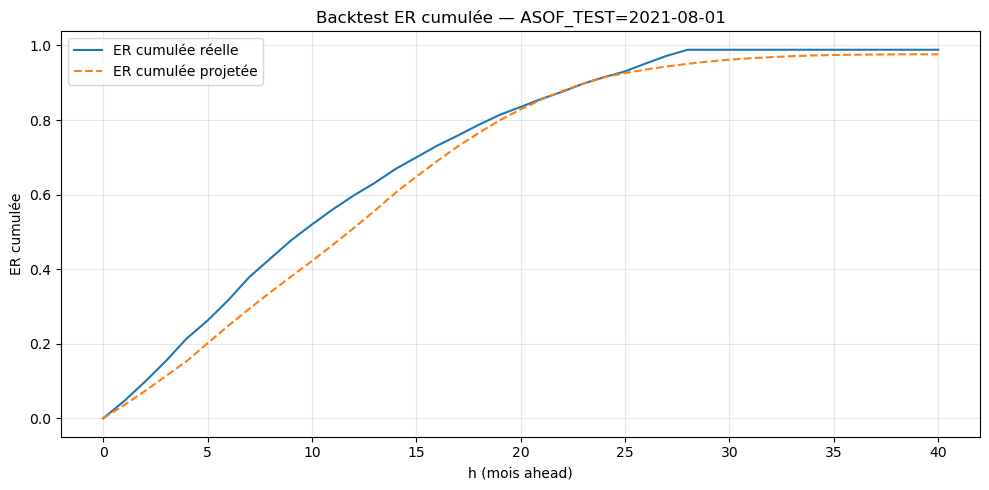

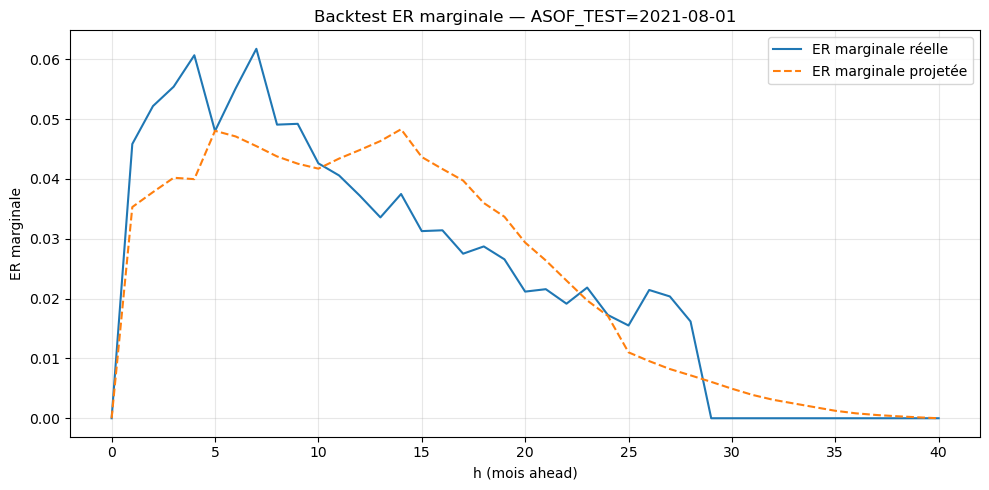

In [10]:
# =========================================================
# 6) PLOTS
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(cmp["h"], cmp["ER_cumulee_real"], label="ER cumulée réelle")
plt.plot(cmp["h"], cmp["ER_cumulee_proj"], "--", label="ER cumulée projetée")
plt.xlabel("h (mois ahead)")
plt.ylabel("ER cumulée")
plt.title(f"Backtest ER cumulée — ASOF_TEST={ASOF_TEST.date()}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cmp["h"], cmp["ER_marginal_real"], label="ER marginale réelle")
plt.plot(cmp["h"], cmp["ER_marginal_proj"], "--", label="ER marginale projetée")
plt.xlabel("h (mois ahead)")
plt.ylabel("ER marginale")
plt.title(f"Backtest ER marginale — ASOF_TEST={ASOF_TEST.date()}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation des resultats du backtest

#### Metriques quantitatives

| Metrique | Valeur | Interpretation |
|---|---|---|
| MAE marginale | **0.00642** | En moyenne, l'écart absolu entre taux mensuel réel et projeté est de 0.64 point de % |
| RMSE marginale | **0.00832** | Écart quadratique moyen de 0.83 point de % |
| ER cumulée réelle h=40 | **98.85%** | Presque l'intégralité du portefeuille a subi un RA sur l'horizon de 40 mois |
| ER cumulée projetée h=40 | **97.63%** | Sous-estimation finale de 1.22 point de % |

#### Lecture du graphique ER cumulee

La courbe pointillée (projection) suit très fidèlement la courbe pleine (réel) sur l'ensemble de l'horizon. On observe :

- **h = 0 à 20 mois** : légère sous-estimation du modèle (courbe projetée en-dessous), mais l'écart reste inférieur à 5 points de %.
- **h = 20 à 28 mois** : les deux courbes se croisent et coïncident très bien.
- **h > 28 mois** : la courbe réelle atteint ~99% tandis que la projection plafonne à ~97.6%, correspondant à l'écart final de 1.22 point de %.

La légère sous-estimation à long terme est cohérente avec $\delta_3 < 0$ : la calibration avait corrigé une surestimation sur le jeu de calibration, et cette correction s'avère légèrement excessive sur la population test.

#### Qualite globale du modele

Un MAE de 0.64% sur la ER marginale est un résultat très satisfaisant pour un modèle de prepayment. Il indique que :

1. Le modèle capture correctement la dynamique temporelle des remboursements anticipés.
2. La calibration en trois deltas est efficace et se généralise bien hors-échantillon.
3. Le pipeline train → calibration → test ne présente pas de surapprentissage notable.

#### Points d'attention

- L'avertissement de non-convergence du GLM mérite d'être surveillé : augmenter `MAXITER` ou changer d'optimiseur pourrait améliorer marginalement les performances.
- La variable `produit2` a été ignorée faute de variance dans `train_fit` — revoir le sous-échantillonnage ou l'encodage produit pourrait enrichir le modèle.
- Les cibles de calibration très élevées (41.7% à 12 mois, 75% à 24 mois) sont caractéristiques d'un portefeuille à forte sensibilité aux taux. Dans un contexte de remontée des taux (post-2022), ces taux pourraient baisser significativement et nécessiter une recalibration.
